
--- Laporan Akurasi Klasifikasi  ---
                   precision    recall  f1-score   support

Maintenance/Error       0.39      0.07      0.12       456
           Normal       0.96      0.99      0.98      9650

         accuracy                           0.95     10106
        macro avg       0.67      0.53      0.55     10106
     weighted avg       0.93      0.95      0.94     10106



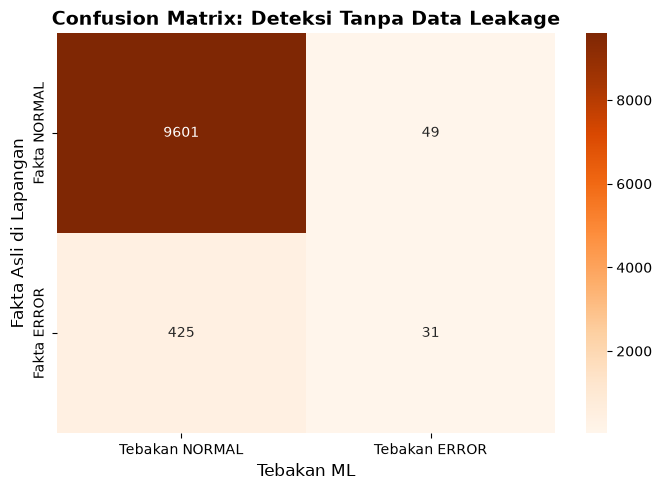

In [7]:
X_real = df[['wind_speed_ms', 'wind_direction_deg']]
y_real = df['turbine_status'] 

# 2. Memecah Data
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_real, y_real, test_size=0.2, random_state=42)

# 3. Melatih Model
model_clf_real = RandomForestClassifier(n_estimators=100, random_state=42)
model_clf_real.fit(X_train_r, y_train_r)

# 4. Evaluasi
prediksi_real = model_clf_real.predict(X_test_r)

print("\n--- Laporan Akurasi Klasifikasi  ---")
print(classification_report(y_test_r, prediksi_real))

# 5. Visualisasi Confusion Matrix Baru
cm_real = confusion_matrix(y_test_r, prediksi_real, labels=['Normal', 'Maintenance/Error'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm_real, annot=True, fmt='d', cmap='Oranges', # Gua ganti warna Orange biar beda sama yang tadi
            xticklabels=['Tebakan NORMAL', 'Tebakan ERROR'], 
            yticklabels=['Fakta NORMAL', 'Fakta ERROR'])

plt.title('Confusion Matrix: Deteksi Tanpa Data Leakage', fontsize=14, fontweight='bold')
plt.xlabel('Tebakan ML', fontsize=12)
plt.ylabel('Fakta Asli di Lapangan', fontsize=12)
plt.tight_layout()
plt.show()

1. Membaca Data...
2. Menyiapkan Fitur (X) dan Target Kategori (y)...
3. Memecah Data (Train-Test Split)...
4. Melatih Model KLASIFIKASI...
5. Ujian Evaluasi (Membuat Confusion Matrix)...

--- Laporan Akurasi Klasifikasi ---
                   precision    recall  f1-score   support

Maintenance/Error       1.00      1.00      1.00       456
           Normal       1.00      1.00      1.00      9650

         accuracy                           1.00     10106
        macro avg       1.00      1.00      1.00     10106
     weighted avg       1.00      1.00      1.00     10106



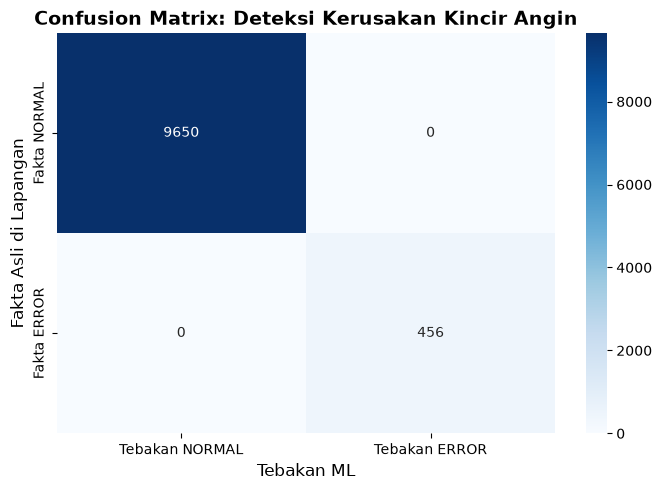

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("1. Membaca Data...")
# Kita pakai SELURUH data sekarang (baik yang Normal maupun yang Error)
df = pd.read_parquet('../data/processed/wind_turbine_cleaned.parquet')

print("2. Menyiapkan Fitur (X) dan Target Kategori (y)...")
# X: Kita jadikan sensor angin dan daya sebagai petunjuk
X = df[['wind_speed_ms', 'wind_direction_deg', 'active_power_kw']]

# y: Targetnya sekarang BUKAN angka daya, tapi KATEGORI status mesin
y = df['turbine_status'] 

print("3. Memecah Data (Train-Test Split)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("4. Melatih Model KLASIFIKASI...")
# Menggunakan Classifier untuk menebak kategori
model_clf = RandomForestClassifier(n_estimators=100, random_state=42)
model_clf.fit(X_train, y_train)

print("5. Ujian Evaluasi (Membuat Confusion Matrix)...")
prediksi_status = model_clf.predict(X_test)

# Menampilkan Laporan Teks
print("\n--- Laporan Akurasi Klasifikasi ---")
print(classification_report(y_test, prediksi_status))

# Membuat Visualisasi Heatmap Confusion Matrix
cm = confusion_matrix(y_test, prediksi_status, labels=['Normal', 'Maintenance/Error'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Tebakan NORMAL', 'Tebakan ERROR'], 
            yticklabels=['Fakta NORMAL', 'Fakta ERROR'])

plt.title('Confusion Matrix: Deteksi Kerusakan Kincir Angin', fontsize=14, fontweight='bold')
plt.xlabel('Tebakan ML', fontsize=12)
plt.ylabel('Fakta Asli di Lapangan', fontsize=12)
plt.tight_layout()
plt.show()